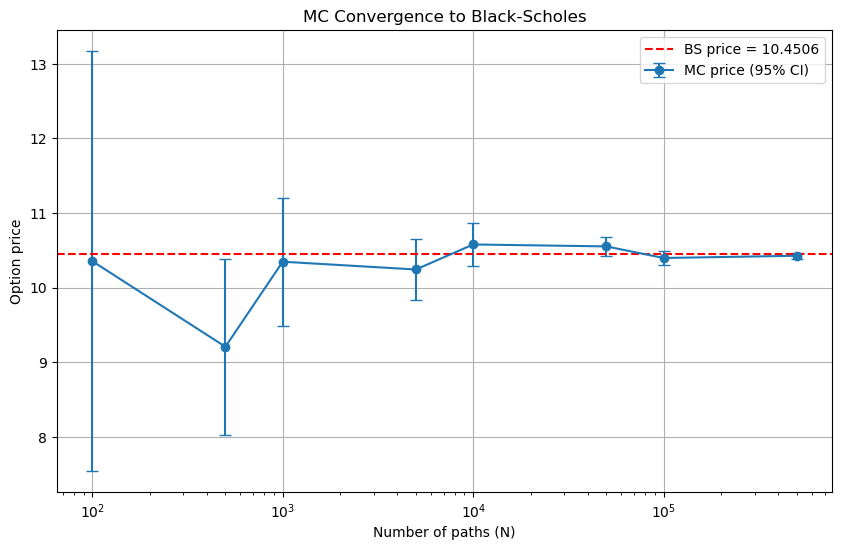

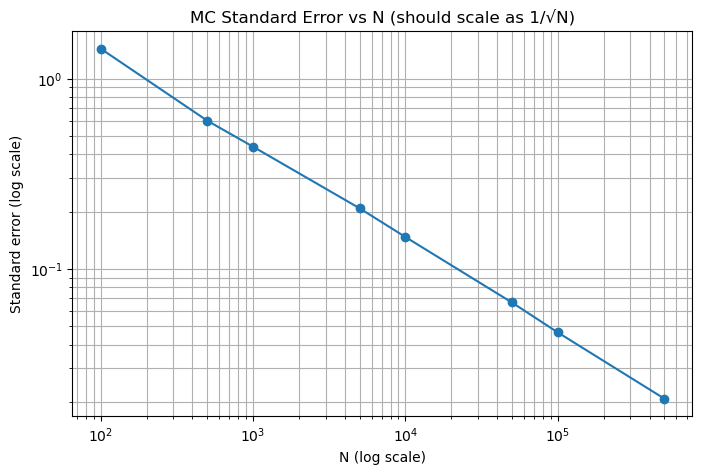

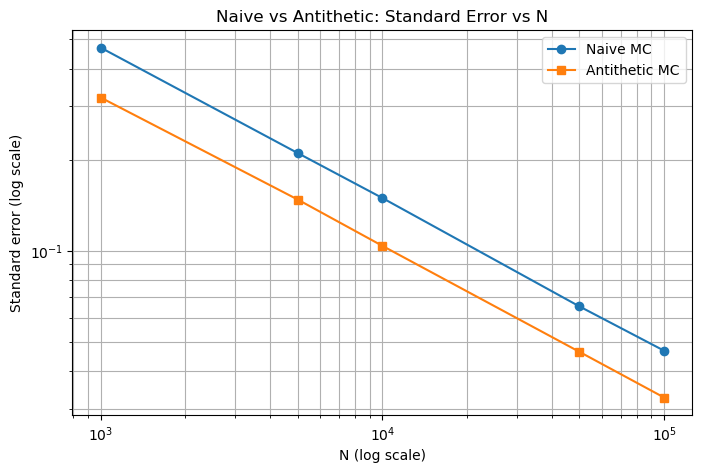

Naive SE: 0.14716
Antithetic SE: 0.10136
Variance reduction ratio: 2.11x


In [19]:
from scipy.stats import norm
import numpy as np
import time
import import_ipynb
from Geometric_Brownian_Motion import simulate_GBM, simulate_GBM_antithetic
from Black_Scholes_Closed_Form import european_mc, european_mc_antithetic
#from Greeks import pathwise_delta, pathwise_vega, bs_delta, bs_vega
import matplotlib.pyplot as plt
from scipy.stats import qmc

In [6]:
S0, K, r, sigma, T = 100, 100, 0.05, 0.2, 1.0

In [9]:
def asian_mc(S0, K, r, sigma, T, n, n_paths, average_type="arithmetic", type="call"):
    t, S = simulate_GBM(S0, r, sigma, T, n, n_paths)
    
    if average_type == "arithmetic":
        avg = S[:, 1:].mean(axis=1)  # exclude t=0 column, average over the path
    else:  # geometric
        avg = np.exp(np.log(S[:, 1:]).mean(axis=1))
    
    if type == "call":
        payoff = np.maximum(avg - K, 0)
    else:
        payoff = np.maximum(K - avg, 0)
    
    discounted = np.exp(-r*T) * payoff
    price = discounted.mean()
    se = discounted.std(ddof=1) / np.sqrt(n_paths)
    return price, se

In [10]:
def geometric_asian_bs(S0, K, r, sigma, T, type="call"):
    sigma_adj = sigma / np.sqrt(3)
    r_adj = 0.5 * (r - 0.5*sigma**2 + sigma_adj**2)
    
    d1 = (np.log(S0/K) + (r_adj + 0.5*sigma_adj**2)*T) / (sigma_adj*np.sqrt(T))
    d2 = d1 - sigma_adj*np.sqrt(T)
    
    if type == "call":
        price = np.exp(-r*T) * (S0*np.exp(r_adj*T)*norm.cdf(d1) - K*norm.cdf(d2))
    else:
        price = np.exp(-r*T) * (K*norm.cdf(-d2) - S0*np.exp(r_adj*T)*norm.cdf(-d1))
    return price

In [11]:
geo_mc_price, geo_se = asian_mc(S0, K, r, sigma, T, n=252, n_paths=100000, average_type="geometric", type="call")
geo_bs_price = geometric_asian_bs(S0, K, r, sigma, T, "call")

print(f"Geometric Asian MC:  {geo_mc_price:.4f} ± {1.96*geo_se:.4f}")
print(f"Geometric Asian BS:  {geo_bs_price:.4f}")

Geometric Asian MC:  5.5520 ± 0.0478
Geometric Asian BS:  5.5468


In [13]:
arith_price, arith_se = price_asian_mc(S0, K, r, sigma, T, n=252, n_paths=100000, average_type="arithmetic", type="call")
print(f"Arithmetic Asian:    {arith_price:.4f} ± {1.96*arith_se:.4f}")

Arithmetic Asian:    5.8045 ± 0.0497


In [15]:
def price_lookback_mc(S0, r, sigma, T, n, n_paths, type="call"):
    t, S = simulate_GBM(S0, r, sigma, T, n, n_paths)
    S_T = S[:, -1]
    
    if type == "call":
        running_min = S.min(axis=1)
        payoff = S_T - running_min
    else:
        running_max = S.max(axis=1)
        payoff = running_max - S_T
    
    discounted = np.exp(-r*T) * payoff
    price = discounted.mean()
    se = discounted.std(ddof=1) / np.sqrt(n_paths)
    return price, se

In [20]:
lookback_price, lb_se = price_lookback_mc(S0, r, sigma, T, n=252, n_paths=100000, type="call")
vanilla_price, _ = european_mc(S0, K, r, sigma, T, n=252, n_paths=100000, type="call")

print(f"Lookback call: {lookback_price:.4f}")
print(f"Vanilla call (K=S0): {vanilla_price:.4f}")

Lookback call: 16.6389
Vanilla call (K=S0): 10.4251
